# 02 — Simulated Annealing

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- comprender por qué aceptar temporalmente soluciones peores puede ser útil;
- implementar Simulated Annealing desde cero;
- interpretar el efecto de la temperatura y el calendario de enfriamiento;
- comparar Simulated Annealing con Hill Climbing.

![HillClimbing](https://drive.google.com/uc?export=view&id=13a1dTy2bf9BsgeSZH-cXqJndS1ZKU4DP)



## 1. Un paisaje con varios óptimos

Maximizaremos una función unidimensional multimodal:

$$
f(x)=\sin(3x)+0.35\sin(9x)-0.03(x-2)^2
$$

El algoritmo solo observará valores cercanos al estado actual.

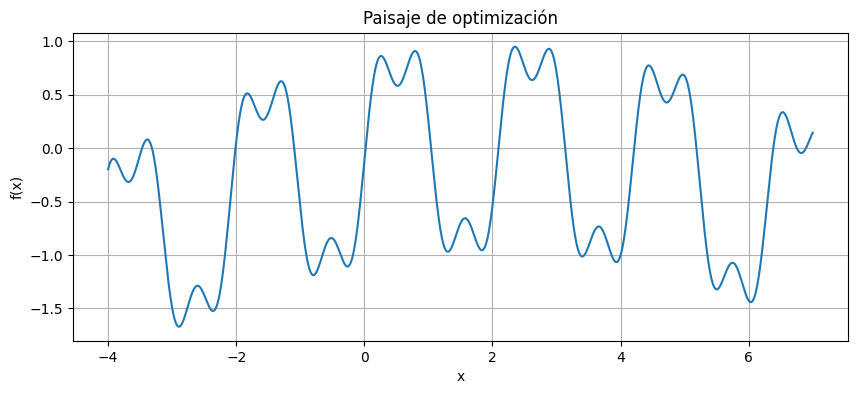

Mejor punto aproximado en la malla: x=2.355, f(x)=0.951


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 21
random.seed(SEED)
np.random.seed(SEED)


def objective(x):
    return np.sin(3 * x) + 0.35 * np.sin(9 * x) - 0.03 * (x - 2) ** 2

LOWER, UPPER = -4.0, 7.0
xs = np.linspace(LOWER, UPPER, 1500)
ys = objective(xs)

plt.figure(figsize=(10, 4))
plt.plot(xs, ys)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Paisaje de optimización')
plt.grid(True)
plt.show()

best_grid_x = xs[np.argmax(ys)]
print(f'Mejor punto aproximado en la malla: x={best_grid_x:.3f}, f(x)={objective(best_grid_x):.3f}')

## 2. Hill Climbing estocástico como línea base

Propondremos un vecino mediante una perturbación aleatoria pequeña. Hill Climbing acepta el candidato únicamente cuando mejora la función objetivo.

In [2]:
def random_neighbor(x, step_size, rng, lower=LOWER, upper=UPPER):
    candidate = x + rng.uniform(-step_size, step_size)
    return min(upper, max(lower, candidate))


def stochastic_hill_climbing(x0, iterations=300, step_size=0.35, seed=0):
    rng = random.Random(seed)
    x = x0
    trajectory = [(x, float(objective(x)))]

    for _ in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        if objective(candidate) > objective(x):
            x = candidate
        trajectory.append((x, float(objective(x))))

    return x, trajectory

x0 = -2.5
hill_x, hill_trajectory = stochastic_hill_climbing(x0, seed=SEED)
print(f'Hill Climbing: x={hill_x:.3f}, f(x)={objective(hill_x):.3f}')

Hill Climbing: x=-2.603, f(x)=-1.288


## 3. Regla de aceptación

Sea

$$
\Delta = f(x')-f(x)
$$

Para maximización:

- si $\Delta>0$, aceptamos el candidato;
- si $\Delta\leq 0$, lo aceptamos con probabilidad

$$
P(\text{aceptar})=\exp\left(\frac{\Delta}{T}\right)
$$

Cuando $T$ es alta, el algoritmo explora. Cuando $T$ disminuye, se vuelve más selectivo.

In [3]:
def simulated_annealing(
    x0,
    iterations=800,
    initial_temperature=1.5,
    cooling_rate=0.992,
    step_size=0.45,
    seed=0
):
    rng = random.Random(seed)
    x = x0
    current_value = float(objective(x))
    best_x, best_value = x, current_value
    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        candidate_value = float(objective(candidate))
        delta = candidate_value - current_value

        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        accepted = rng.random() < probability

        if accepted:
            x, current_value = candidate, candidate_value

        if current_value > best_value:
            best_x, best_value = x, current_value

        records.append({
            'iteration': iteration,
            'x': x,
            'value': current_value,
            'best_value': best_value,
            'temperature': temperature,
            'delta': delta,
            'probability': probability,
            'accepted': accepted
        })
        temperature *= cooling_rate

    return best_x, best_value, records

sa_x, sa_value, records = simulated_annealing(x0, seed=SEED)
print(f'Simulated Annealing: x={sa_x:.3f}, f(x)={sa_value:.3f}')

Simulated Annealing: x=0.791, f(x)=0.911


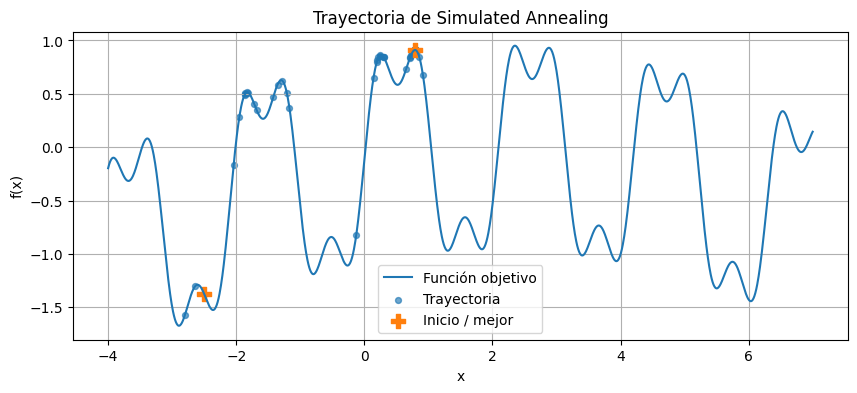

In [4]:
trajectory_x = [r['x'] for r in records]
trajectory_y = [r['value'] for r in records]

plt.figure(figsize=(10, 4))
plt.plot(xs, ys, label='Función objetivo')
plt.scatter(trajectory_x[::12], trajectory_y[::12], s=18, alpha=0.65, label='Trayectoria')
plt.scatter([x0, sa_x], [objective(x0), sa_value], s=100, marker='P', label='Inicio / mejor')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trayectoria de Simulated Annealing')
plt.legend()
plt.grid(True)
plt.show()

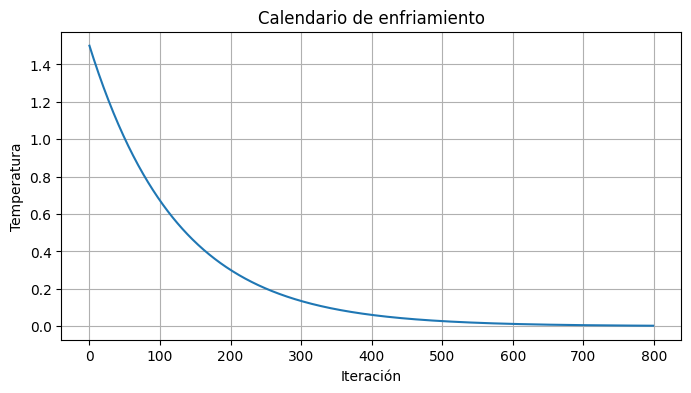

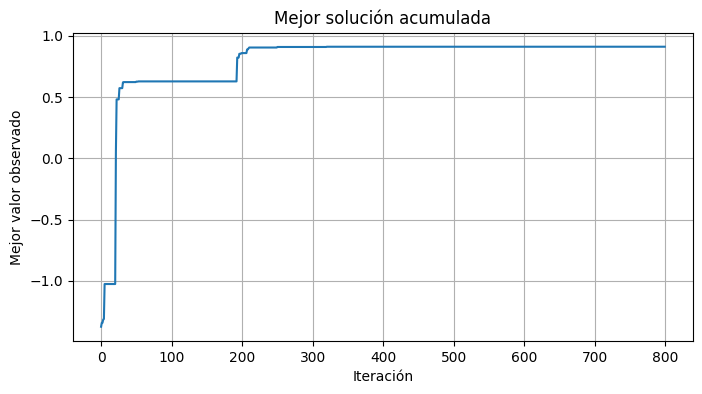

In [5]:
iterations = [r['iteration'] for r in records]
temperatures = [r['temperature'] for r in records]
best_values = [r['best_value'] for r in records]

plt.figure(figsize=(8, 4))
plt.plot(iterations, temperatures)
plt.xlabel('Iteración')
plt.ylabel('Temperatura')
plt.title('Calendario de enfriamiento')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(iterations, best_values)
plt.xlabel('Iteración')
plt.ylabel('Mejor valor observado')
plt.title('Mejor solución acumulada')
plt.grid(True)
plt.show()

## 4. Comparación estadística

Una sola corrida puede ser engañosa. Compararemos ambos algoritmos usando múltiples semillas y el mismo punto inicial.

Hill Climbing — media: -0.380, mejor: 0.628
Simulated Annealing — media: 0.527, mejor: 0.951


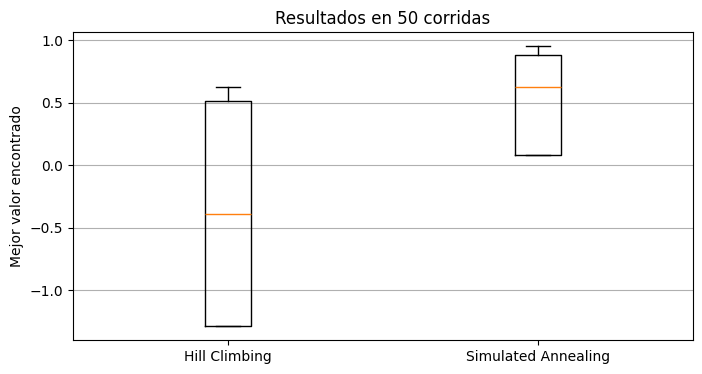

In [6]:
hill_results = []
sa_results = []

for seed in range(50):
    hx, _ = stochastic_hill_climbing(x0, seed=seed)
    sx, sv, _ = simulated_annealing(x0, seed=seed)
    hill_results.append(float(objective(hx)))
    sa_results.append(sv)

print(f'Hill Climbing — media: {np.mean(hill_results):.3f}, mejor: {np.max(hill_results):.3f}')
print(f'Simulated Annealing — media: {np.mean(sa_results):.3f}, mejor: {np.max(sa_results):.3f}')

plt.figure(figsize=(8, 4))
plt.boxplot([hill_results, sa_results], tick_labels=['Hill Climbing', 'Simulated Annealing'])
plt.ylabel('Mejor valor encontrado')
plt.title('Resultados en 50 corridas')
plt.grid(True, axis='y')
plt.show()

## Actividades

### Actividad 1 — Temperatura inicial

Evalúa $T_0\in\{0.01,0.1,0.5,1,3,10\}$. Para cada valor realiza 30 corridas y registra:

- valor medio de la mejor solución;
- desviación estándar;
- porcentaje de corridas que alcanzan un valor cercano al mejor global aproximado.

In [7]:
# Actividad 1 — efecto de la temperatura inicial
temperatures_to_test = [0.01, 0.1, 0.5, 1, 3, 10]

# Usamos el óptimo aproximado por malla (celda 4) como referencia de "óptimo global".
best_global_value = float(objective(best_grid_x))
tolerance = 0.05  # qué tan cerca de best_global_value cuenta como "cercano al óptimo"

experiment = []

for temperature in temperatures_to_test:
    values = []
    for seed in range(30):
        _, value, _ = simulated_annealing(x0, initial_temperature=temperature, seed=seed)
        values.append(value)

    values = np.array(values)
    mean_value = values.mean()
    std_value = values.std()
    pct_near_global = 100 * np.mean(values >= best_global_value - tolerance)

    experiment.append({
        'initial_temperature': temperature,
        'mean_value': mean_value,
        'std_value': std_value,
        'pct_near_global': pct_near_global
    })

print(f"{'T0':>6} | {'media':>8} | {'std':>8} | {'% cerca del óptimo':>20}")
for row in experiment:
    print(f"{row['initial_temperature']:>6} | {row['mean_value']:>8.3f} | "
          f"{row['std_value']:>8.3f} | {row['pct_near_global']:>19.1f}%")

experiment


    T0 |    media |      std |   % cerca del óptimo
  0.01 |    0.537 |    0.203 |                 0.0%
   0.1 |    0.519 |    0.218 |                 0.0%
   0.5 |    0.419 |    0.280 |                 3.3%
     1 |    0.483 |    0.298 |                10.0%
     3 |    0.639 |    0.336 |                46.7%
    10 |    0.750 |    0.233 |                53.3%


[{'initial_temperature': 0.01,
  'mean_value': np.float64(0.536859789614349),
  'std_value': np.float64(0.20338321890306546),
  'pct_near_global': np.float64(0.0)},
 {'initial_temperature': 0.1,
  'mean_value': np.float64(0.5186573675386745),
  'std_value': np.float64(0.21831672728543458),
  'pct_near_global': np.float64(0.0)},
 {'initial_temperature': 0.5,
  'mean_value': np.float64(0.4189611136322065),
  'std_value': np.float64(0.27961013024285997),
  'pct_near_global': np.float64(3.3333333333333335)},
 {'initial_temperature': 1,
  'mean_value': np.float64(0.4829598576218552),
  'std_value': np.float64(0.2980845946987985),
  'pct_near_global': np.float64(10.0)},
 {'initial_temperature': 3,
  'mean_value': np.float64(0.6393733812947449),
  'std_value': np.float64(0.3356984387511465),
  'pct_near_global': np.float64(46.666666666666664)},
 {'initial_temperature': 10,
  'mean_value': np.float64(0.7497419634190947),
  'std_value': np.float64(0.23314916857848678),
  'pct_near_global': np.f

### Actividad 2 — Enfriamiento

Compara diferentes valores de $\alpha$ en

$$
T_{t+1}=\alpha T_t
$$

Explica por qué un enfriamiento demasiado rápido puede convertir el algoritmo en Hill Climbing.

  alpha |    media |      std
    0.9 |    0.381 |    0.283
   0.95 |    0.383 |    0.286
   0.99 |    0.487 |    0.328
  0.995 |    0.571 |    0.322
  0.999 |    0.851 |    0.183


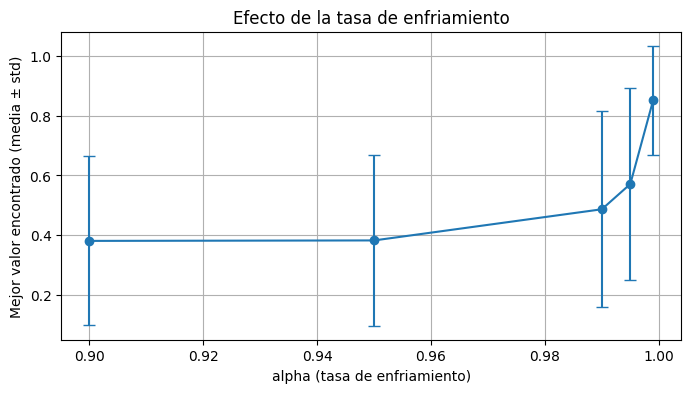

In [8]:
# Actividad 2 — efecto de la tasa de enfriamiento (alpha)
alphas_to_test = [0.90, 0.95, 0.99, 0.995, 0.999]

cooling_experiment = []

for alpha in alphas_to_test:
    values = []
    for seed in range(30):
        _, value, _ = simulated_annealing(x0, cooling_rate=alpha, seed=seed)
        values.append(value)

    values = np.array(values)
    cooling_experiment.append({
        'alpha': alpha,
        'mean_value': values.mean(),
        'std_value': values.std()
    })

print(f"{'alpha':>7} | {'media':>8} | {'std':>8}")
for row in cooling_experiment:
    print(f"{row['alpha']:>7} | {row['mean_value']:>8.3f} | {row['std_value']:>8.3f}")

plt.figure(figsize=(8, 4))
plt.errorbar(
    [r['alpha'] for r in cooling_experiment],
    [r['mean_value'] for r in cooling_experiment],
    yerr=[r['std_value'] for r in cooling_experiment],
    marker='o', capsize=4
)
plt.xlabel('alpha (tasa de enfriamiento)')
plt.ylabel('Mejor valor encontrado (media ± std)')
plt.title('Efecto de la tasa de enfriamiento')
plt.grid(True)
plt.show()


**Respuesta — Actividad 2:**

Con `alpha` bajo (por ejemplo 0.90), la temperatura cae muy rápido: en pocas iteraciones `T` se vuelve casi cero, y `exp(delta/T) ≈ 0` para cualquier `delta` negativo. A partir de ese punto, el algoritmo **solo acepta candidatos que mejoran estrictamente** — exactamente la regla de Hill Climbing. Es decir, un enfriamiento demasiado rápido desperdicia la ventaja principal de Simulated Annealing (la fase exploratoria donde acepta soluciones peores) y el algoritmo se queda atrapado en el primer óptimo local que encuentra, igual que Hill Climbing estocástico.

Con `alpha` alto (cercano a 1, por ejemplo 0.999), la temperatura se mantiene alta por más tiempo, dando más oportunidades de escapar de óptimos locales antes de "congelarse" — a costa de necesitar más iteraciones para converger.

### Actividad 3 — Problema discreto

Adapta Simulated Annealing al problema de hospitales del notebook anterior. Recuerda que, al minimizar, puedes definir

$$
\Delta = C(	actual)-C(candidato)
$$

para conservar la misma lógica de aceptación usada en este notebook.

```python
def simulated_annealing_discrete(
    initial_state,
    cost_fn,          # C(estado) -> costo total (a minimizar)
    neighbor_fn,       # genera un vecino aleatorio del estado actual
    iterations=2000,
    initial_temperature=5.0,
    cooling_rate=0.995,
    seed=0
):
    rng = random.Random(seed)
    state = initial_state
    current_cost = cost_fn(state)
    best_state, best_cost = state, current_cost
    temperature = initial_temperature

    for _ in range(iterations):
        candidate = neighbor_fn(state, rng)
        candidate_cost = cost_fn(candidate)

        # Para minimizar: delta = costo_actual - costo_candidato
        # delta > 0 significa que el candidato es MEJOR (más barato)
        delta = current_cost - candidate_cost

        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        if rng.random() < probability:
            state, current_cost = candidate, candidate_cost

        if current_cost < best_cost:
            best_state, best_cost = state, current_cost

        temperature *= cooling_rate

    return best_state, best_cost
```

La clave es esa definición de `delta` (invertida respecto al notebook, porque aquí minimizamos en vez de maximizar) — así se conserva exactamente la misma regla de aceptación `P = exp(delta/T)`.

## Preguntas de cierre

1. ¿Por qué Simulated Annealing conserva la mejor solución observada, además de la solución actual?
2. ¿Qué ocurre si la temperatura nunca disminuye?
3. ¿Qué ocurre si la temperatura inicial es prácticamente cero?
4. ¿Simulated Annealing garantiza el óptimo global con un número finito de iteraciones?

### Respuestas — preguntas de cierre

1. **¿Por qué Simulated Annealing conserva la mejor solución observada, además de la actual?** Porque la solución "actual" puede empeorar temporalmente a propósito (eso es lo que permite escapar de óptimos locales), así que en cualquier momento podría estar peor que el mejor punto ya visitado. Si no se guardara `best` por separado, el algoritmo podría terminar reportando una solución peor que otra que ya había encontrado antes.

2. **¿Qué ocurre si la temperatura nunca disminuye?** El algoritmo nunca se vuelve más selectivo: sigue aceptando movimientos que empeoran la solución con la misma probabilidad durante toda la ejecución. Se comporta como una caminata aleatoria que jamás converge ni explota lo que ha aprendido — nunca entra en la fase de "afinar" la mejor zona encontrada.

3. **¿Qué ocurre si la temperatura inicial es prácticamente cero?** `exp(delta/T)` tiende a 0 para cualquier `delta` negativo cuando `T→0`, así que desde el primer paso solo se aceptan candidatos que mejoran estrictamente. El algoritmo se comporta exactamente como Hill Climbing estocástico, sin ninguna fase exploratoria.

4. **¿Simulated Annealing garantiza el óptimo global con un número finito de iteraciones?** No. La convergencia teórica al óptimo global solo está garantizada bajo un enfriamiento infinitamente lento (un número infinito de iteraciones). Con un número finito de pasos, como en la práctica, puede quedar atrapado en un óptimo local — aunque tiene mayor probabilidad de escapar de ellos que Hill Climbing, no hay garantía.